Q1. Understanding Feature Distributions (Iris Dataset)

Context: Before training any ML model, we analyze feature distributions.

Dataset: Load Iris dataset from sklearn

Tasks:

1. Extract feature matrix as NumPy array
2. Compute:
Mean
Median
Standard deviation
Variance (for each feature)
3. Identify:
Which feature has highest variability and why it matters in ML
4. Convert any one feature into shape (n,1) and explain why ML models expect this format

In [30]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

iris=load_iris()
iris.data  


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [37]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
df_raw = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df = df_raw.copy()

# Task 1: Extract feature matrix as NumPy array
X = df.values
print("Shape of feature matrix:", X.shape)

# Task 2: Compute mean, median, standard deviation, and variance for each feature
mean = df.mean()
median = df.median()
std_dev = df.std()
variance = df.var()
print("\nMean:\n", mean)
print("\nMedian:\n", median)
print("\nStd dev:\n", std_dev)
print("\nVariance:\n", variance)

# Task 3: Identify the feature with highest variability
max_var_feature = variance.idxmax()
print("\nFeature with highest variance:", max_var_feature)
print("Variance value:", variance.max())

# Task 4: Reshape one feature to (n,1) — ML models expect 2D input (n_samples, n_features)
petal_length = df[['petal length (cm)']]
print

Shape of feature matrix: (150, 4)

Mean:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Median:
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

Std dev:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64

Variance:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64

Feature with highest variance: petal length (cm)
Variance value: 3.1162778523489942


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

Q2. Data Selection for Model Input

Context: Models are trained on selective features, not full raw data.

Dataset: Iris

Tasks:

1. Extract:
First 100 samples
Only last 2 features
2. Use boolean masking:
Select samples where petal length is greater than dataset mean
3. Count selected samples
4. Explain how this relates to feature-based filtering in ML

In [47]:
#1.Extract: First 100 samples Only last 2 features
print(df.iloc[:100,-2:])

#2. Use boolean masking: Select samples where petal length is greater than dataset mean
mean_petal_length=df['petal length (cm)'].mean()
mask=df['petal length (cm)']>mean_petal_length
filtered=df[mask]
print(filtered.head())

#3. Count selected samples
count=filtered.shape[0]
print("\nCount of selected samples:", count)

    petal length (cm)  petal width (cm)
0                 1.4               0.2
1                 1.4               0.2
2                 1.3               0.2
3                 1.5               0.2
4                 1.4               0.2
..                ...               ...
95                4.2               1.2
96                4.2               1.3
97                4.3               1.3
98                3.0               1.1
99                4.1               1.3

[100 rows x 2 columns]
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
50                7.0               3.2                4.7               1.4
51                6.4               3.2                4.5               1.5
52                6.9               3.1                4.9               1.5
53                5.5               2.3                4.0               1.3
54                6.5               2.8                4.6               1.5

Count of selected samples: 93


Q3. Feature Scaling using NumPy (Very Important)

Context: Most ML models require normalized data.

Dataset: Iris (NumPy array)

Tasks:

1. Apply standardization:

$$
X' = \frac{X - \mu}{\sigma}
$$
	​2. 

Verify:
Mean ≈ 0
Std ≈
on

In [52]:
mean= np.mean(X, axis=0)
std=np.std(X, axis=0)
X_scaled=(X-mean)/std
print(X.shape)
print(np.mean(X_scaled, axis=0))
print(np.std(X_scaled, axis=0))

(150, 4)
[-4.73695157e-16 -7.81597009e-16 -4.26325641e-16 -4.73695157e-16]
[1. 1. 1. 1.]


Q4. Dataset Understanding (Titanic Dataset)

Context: First step in ML pipeline is dataset inspection.

Dataset: Titanic (Seaborn)

Tasks:

1. Display:
head(), tail()
info(), describe()
2. Identify:
Missing values per column
Numerical vs categorical features
3. Explain:
Why identifying feature types is important before modeling

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
df=sns.load_dataset("titanic")
#1 
print(df.head())
print(df.tail())
print(df.info())
print(df.describe()) #numerical
print(df.describe(include="object")) #categorical
#2 
print(df.isnull().sum())
num_features=df.select_dtypes(include=np.number).columns.tolist()
print(num_features)
cat_features=df.select_dtypes(exclude=np.number

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0      0      0  30.00        S

Q5. Filtering Data for Business Logic

Context: Real ML problems require filtering relevant populations.

Dataset: Titanic

Tasks:

1. Filter:
Female passengers in 1st class
2. Compute:
Survival rate for this group
3. Compare with overall survival rate
4. Interpret:
What insight can be used in ML feature engineering

In [76]:
female_first_class=df[(df["sex"]=="female")& (df["pclass"]==1)]
female_first_class_survival= female_first_class["survived"].mean()
overall_survival_rate=df["survived"].mean()
print(female_first_class.shape[0])
print(female_first_class_survival)
print(overall_survival_rate)

94
0.9680851063829787
0.3838383838383838


Q6. Handling Missing Data (Critical ML Step)

Context: Models cannot handle null values.

Dataset: Titanic

Tasks:

1. Fill missing age using median
2. Fill missing embarked using mode
3. Drop deck column
4. Explain:
Why different strategies are used for different columns

In [89]:
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode())
#df=df.drop(columns=['deck'])
print(df.isnull().sum())
print("As there are so many missing values for deck, we dropped that column.\nfor age, we filled them with median as it is numerical.\nfor embarked, we have used mode as it categorical")
    

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64
As there are so many missing values for deck, we dropped that column.
for age, we filled them with median as it is numerical.
for embarked, we have used mode as it categorical


Q7. Feature Engineering for Model Improvement

Context: Raw data is rarely useful—features must be created.

Dataset: Titanic

Tasks:

1. Create:
family_size = sibsp + parch + 1
2. Create:
is_alone (binary feature)
3. Compute survival rate by is_alone
4. Explain:
Why engineered features improve ML models

In [7]:
import numpy as np
import seaborn as sns
df=sns.load_dataset("titanic")
df['family_size']=df['sibsp']+df['parch']+1
df.head()
df['is_alone']=(df['family_size']==1).astype(int)
df.head()
survival_rate=df.groupby('is_alone')['survived'].mean()
print(f"Survived Lonely: {survival_rate[0]:.2f}")
print(f"Survived with family: {survival_rate[1]:.2f}")

Survived Lonely: 0.51
Survived with family: 0.30


Q8. Group-Based Insights (Customer Segmentation Logic)

Context: ML models often depend on aggregated patterns.

Dataset: Tips

Tasks:

1. Compute:
Average tip by day
Total bill by gender
2. Create new feature:
tip_percentage
3. Identify:
Which day has highest tipping behavior
4. Explain:
How this helps in segmentation models

In [19]:
import numpy as np
import seaborn as sns
df=sns.load_dataset("tips")
average_tip_per_day=df.groupby('day',observed=True)['tip'].mean()
total_tip_per_sex=df.groupby('sex', observed=True)['tip'].sum()
df.head()
df['tip_percentage']=(df['tip']/df['total_bill']).round(4)*100
best_day = df.groupby('day', observed=True)['tip_percentage'].mean().idxmax()
highest_tip = df.groupby('day', observed=True)['tip_percentage'].mean().max()
df.head()
print(average_tip_per_day)
print(total_tip_per_sex)
print("Best Day:",best_day)
print(f"Highest Tip: {highest_tip:.2f}")

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64
sex
Male      485.07
Female    246.51
Name: tip, dtype: float64
Best Day: Fri
Highest Tip: 16.99


Q9. Advanced Filtering + Subsetting

Context: Training data is often filtered based on business rules.

Dataset: Tips

Tasks:

1. Filter:
total_bill > 20 AND tip < 3
2. Select only relevant columns
3. Analyze:
Is this segment under-tipping?
4. Explain:
How such filtering helps anomaly detection

In [22]:
import seaborn as sns
import pandas as pd
df_raw = sns.load_dataset("tips")
tips = df_raw.copy()
# Apply filtering
filtered_df = df[(df["total_bill"] > 20) & (df["tip"] < 3)]

# Select relevant columns
segment = filtered_df[[
    "total_bill",
    "tip",
    "tip_percentage",
    "day",
    "sex"
]]

# Analysis
segment_avg_tip_pct = segment["tip_percentage"].mean()
overall_avg_tip_pct = df["tip_percentage"].mean()

print("Filtered Segment:\n", segment.head())
print("\nSegment Average Tip %:", round(segment_avg_tip_pct, 2))
print("Overall Average Tip %:", round(overall_avg_tip_pct, 2))
print("\nNumber of Under-Tipping Cases:", len(segment))

print("\n--- Analysis ---")

if segment_avg_tip_pct < overall_avg_tip_pct:
    print("Yes, this segment is under-tipping.")
    print("Reason: Customers have high total bills (>20) but give lower tips (<3).")
    print("Their average tip percentage is lower than the overall dataset average.")
else:
    print("No, this segment is not under-tipping compared to overall behavior.")

print("\n--- Anomaly Detection Explanation ---")
print("This filtering identifies unusual behavior where high spending customers give disproportionately low tips.")
print("Such deviations from normal tipping patterns can be treated as anomalies.")
print("In ML systems, similar rule-based filtering helps detect fraud, risk cases, or abnormal transactions.")
print("These filtered segments can be used to create anomaly flags or train classification models.")

Filtered Segment:
     total_bill   tip  tip_percentage  day     sex
21       20.29  2.75           13.55  Sat  Female
33       20.69  2.45           11.84  Sat  Female
48       28.55  2.05            7.18  Sun    Male
57       26.41  1.50            5.68  Sat  Female
68       20.23  2.01            9.94  Sat    Male

Segment Average Tip %: 9.08
Overall Average Tip %: 16.08

Number of Under-Tipping Cases: 21

--- Analysis ---
Yes, this segment is under-tipping.
Reason: Customers have high total bills (>20) but give lower tips (<3).
Their average tip percentage is lower than the overall dataset average.

--- Anomaly Detection Explanation ---
This filtering identifies unusual behavior where high spending customers give disproportionately low tips.
Such deviations from normal tipping patterns can be treated as anomalies.
In ML systems, similar rule-based filtering helps detect fraud, risk cases, or abnormal transactions.
These filtered segments can be used to create anomaly flags or train

Q10. Data Transformation for Model Input (NumPy)

Context: ML models require structured numeric arrays.

Tasks:

1. Create two arrays of shape (3,2)
2. Perform:
Vertical stacking
Horizontal stacking
3. Reshape into (2,6)
4. Explain:
Why reshaping is required in ML pipelines

In [21]:
import numpy as np
array_a = np.array([[1,3],
         [8,6],
         [6,9]])
array_b = np.array([[2,4],
                   [5,7],
                   [7,10]])
vertical_stack = np.vstack((array_a, array_b))
hor_stack = np.hstack((array_a, array_b))
re_vertical_stack = vertical_stack.reshape(2, 6)
re_hor_stack = hor_stack.reshape(2, 6)
print(re_hor_stack )

[[ 1  3  2  4  8  6]
 [ 5  7  6  9  7 10]]


Q11. End-to-End ML Preprocessing Pipeline (Titanic)

Context: Prepare dataset for ML model training

Tasks:

1. Load dataset
2. Handle missing values
3. Encode categorical variables (sex, embarked)
4. Normalize numerical features
5. Convert to NumPy array

Output:

Final feature matrix ready for model training

In [38]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load Titanic dataset from Seaborn
df = sns.load_dataset("titanic")

# 2. Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)          
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)  
df.drop(columns=['deck'], inplace=True)                     

# 3. Encode categorical variables
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['embarked'] = LabelEncoder().fit_transform(df['embarked'])

# 4. Normalize numerical features
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

# 5. Select useful features
features = ['pclass', 'sex', 'age', 'fare', 'embarked']
X = df[features].to_numpy()   # Convert to NumPy array
y = df['survived'].to_numpy() # Target variable

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (891, 5)
Target vector shape: (891,)


C:\Users\tarak\AppData\Local\Temp\ipykernel_14952\476852422.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)          # Fill Age with median
C:\Users\tarak\AppData\Local\Temp\ipykernel_14952\476852422.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

Q12. Feature Selection using Statistical Understanding

Context: Not all features improve model performance.

Dataset: Iris

Tasks:

1. Compute correlation matrix
2. Identify highly correlated features
3. Drop redundant features
4. Explain:
Impact on overfitting and model performance

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


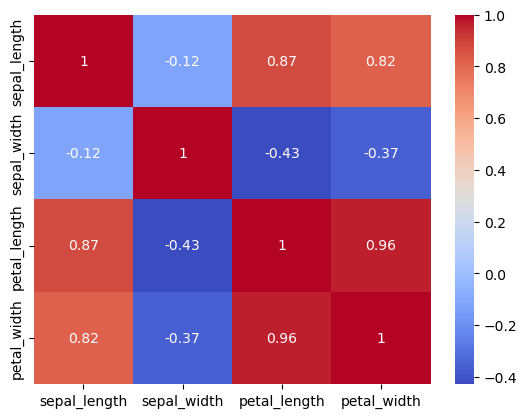

Original shape: (150, 5)
Reduced shape: (150, 4)


In [43]:
import seaborn as sns
import pandas as pd

# Load Iris dataset
df = sns.load_dataset("iris")
# Select numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
# Compute correlation matrix
corr_matrix = numeric_df.corr()
print(corr_matrix)
import matplotlib.pyplot as plt
# Visualize correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()
# Drop petal_width (redundant with petal_length)
df_reduced = df.drop(columns=['petal_width'])
print("Original shape:", df.shape)
print("Reduced shape:", df_reduced.shape)


Q13. Custom Feature Transformation using apply()

Context: Real ML requires custom logic transformation.

Dataset: Titanic

Tasks:

1. Create age_group:
Child / Adult / Senior
2. Use .apply()
3. Compute survival rate per group
4. Interpret:
Which segment has highest survival likelihood

In [48]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset("titanic")

#1 Create age_group: Child / Adult / Senior
def age_category(age):
    if age<18:
        return "Child"
    elif age<60:
        return "Adult"
    else:
        return "Senior"
df['age_group']=df['age'].apply(age_category)
df['age_group']



0       Adult
1       Adult
2       Adult
3       Adult
4       Adult
        ...  
886     Adult
887     Adult
888    Senior
889     Adult
890     Adult
Name: age_group, Length: 891, dtype: object

In [50]:
#Compute survival rate per group
survival_rate=df.groupby('age_group')['survived'].mean()
print(survival_rate)

age_group
Adult     0.386087
Child     0.539823
Senior    0.290640
Name: survived, dtype: float64


In [53]:
#Interpret: Which segment has highest survival likelihood
print("childen has high survival rate")

childen has high survival rate


Q14. Error Analysis Simulation (Model Evaluation Thinking)

Context: Understanding prediction errors is key in ML.

Tasks:

1. Generate 1000 random error values using NumPy
2. Compute:
Mean
Standard deviation
3. Identify outliers:
Using mean ± 2*std
4. Explain:
What high variance means in model performance

In [56]:
import numpy as np
#Generate 1000 random error values using NumPy
errors= np.random.rand(1000)
errors

array([3.47529607e-01, 7.95489227e-01, 2.35730984e-01, 7.03462708e-01,
       9.93230489e-02, 2.80174437e-01, 4.61750275e-01, 9.94398223e-01,
       1.50881229e-02, 4.92715967e-01, 5.31928129e-01, 6.30957526e-01,
       6.58662017e-01, 7.33686643e-01, 5.47708043e-02, 1.78216271e-02,
       7.59282842e-01, 8.15746054e-01, 4.22917235e-01, 6.77287647e-01,
       3.65199747e-01, 2.16735962e-01, 2.42736636e-01, 2.68161385e-01,
       5.96035281e-01, 9.61539966e-01, 4.64628528e-01, 9.97348792e-02,
       8.66464896e-01, 7.24368978e-01, 6.41206830e-01, 9.42843240e-01,
       4.97655133e-01, 3.04496522e-03, 3.32260515e-01, 8.90412418e-01,
       5.58577203e-01, 5.41298482e-01, 6.58743795e-01, 1.48016373e-01,
       9.90497733e-01, 9.98842936e-01, 9.87647309e-02, 9.80705125e-01,
       7.21156679e-02, 8.63855762e-01, 1.01333525e-01, 8.23820065e-01,
       1.08909681e-01, 3.70384410e-01, 1.79696627e-01, 1.99883711e-01,
       2.57180620e-01, 5.63338045e-01, 5.53905231e-02, 8.41142110e-02,
      

In [60]:
#Compute: Mean Standard deviation
mean_error=np.mean(errors)
mean_std=np.std(errors)
print(mean_error)
print(mean_std)

0.49350452372896475
0.29375736498285115


In [62]:
#Identify outliers: Using mean ± 2*std
lower_bound=mean_error-2*mean_std
upper_bound=mean_error+2*mean_std
outliers = errors[(errors < lower_bound) | (errors > upper_bound)]
print("Number of outliers:", len(outliers))
#Explain: What high variance means in model performance
print("high variance means errors arre spread out widely. predictions fluctuate a lot. model may perfom well on traine ddata but it will be inconsistent on not trained data.We can not be reliable")

Number of outliers: 0
high variance means errors arre spread out widely. predictions fluctuate a lot. model may perfom well on traine ddata but it will be inconsistent on not trained data.We can not be reliable


Q15. Business + ML Insight Problem (Tips Dataset)

Context: Convert data analysis into decision-making

Tasks:

1. Create:
tip_percentage
2. Group by:
day and time
3. Identify:
Highest revenue segment
4. Provide:
Recommendation for business strategy
How ML model can use this insight

In [64]:
import seaborn as sns
import pandas as pd
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [65]:
df['tip_percentage']=(df['tip']/df['total_bill'])*100
df['tip_percentage']

0       5.944673
1      16.054159
2      16.658734
3      13.978041
4      14.680765
         ...    
239    20.392697
240     7.358352
241     8.822232
242     9.820426
243    15.974441
Name: tip_percentage, Length: 244, dtype: float64

In [68]:
grouped_data=df.groupby(['day','time']).agg({
    'total_bill':'sum',
    'tip': 'sum', 
    'tip_percentage': 'mean'
}).reset_index()
grouped_data

C:\Users\tarak\AppData\Local\Temp\ipykernel_14952\3267587161.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data=df.groupby(['day','time']).agg({


,day,time,total_bill,tip,tip_percentage
0,Thur,Lunch,1077.55,168.83,16.130074
1,Thur,Dinner,18.78,3.00,15.974441
2,Fri,Lunch,89.92,16.68,18.876489
3,Fri,Dinner,235.96,35.28,15.891611
4,Sat,Lunch,0.00,0.00,NaN
5,Sat,Dinner,1778.40,260.40,15.315172
6,Sun,Lunch,0.00,0.00,NaN
7,Sun,Dinner,1627.16,247.39,16.689729


In [74]:
#Identify: Highest revenue segment
highest_segment = grouped_data.loc[grouped_data['total_bill'].idxmax()]
print("Highest Revenue Segment:\n", highest_segment)

Highest Revenue Segment:
 day                     Sat
time                 Dinner
total_bill           1778.4
tip                   260.4
tip_percentage    15.315172
Name: 5, dtype: object
